# 01. Разведочный анализ данных (EDA)

В данном ноутбуке проводится разведочный анализ данных химических соединений.

Цель EDA — изучить структуру датасета, проверить наличие пропусков, дубликатов, выбросов, оценить распределения целевых переменных IC50, CC50 и SI, а также выявить закономерности, которые могут быть полезны для дальнейшего построения моделей машинного обучения.

In [3]:
# 1. Импорт библиотек

# Импортируем pandas для работы с таблицами и Excel-файлами
import pandas as pd

# Импортируем numpy для численных расчётов
import numpy as np

# Импортируем matplotlib для построения графиков
import matplotlib.pyplot as plt

# Импортируем warnings, чтобы убрать лишние предупреждения в выводе
import warnings

# Отключаем предупреждения, чтобы ноутбук выглядел аккуратнее
warnings.filterwarnings('ignore')

# Настраиваем pandas так, чтобы отображалось больше столбцов датасета
pd.set_option('display.max_columns', 300)

# Настраиваем pandas так, чтобы при необходимости отображалось больше строк
pd.set_option('display.max_rows', 100)

In [4]:
# 2. Загрузка данных

# Импортируем files из Google Colab для загрузки файла с компьютера
from google.colab import files

# Загружаем Excel-файл с исходными данными в среду Colab
uploaded = files.upload()

Saving Данные_для_курсовои_Классическое_МО.xlsx to Данные_для_курсовои_Классическое_МО.xlsx


In [5]:
# 3. Чтение файла

# Считываем Excel-файл в переменную df
df = pd.read_excel('Данные_для_курсовои_Классическое_МО.xlsx')

# Выводим первые 5 строк датасета, чтобы проверить, что файл загрузился корректно
df.head()

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,340.300,384.350449,158,0,0.038844,-0.293526,0.293526,0.038844,0.642857,1.035714,1.321429,14.822266,9.700470,2.600532,-2.343082,2.644698,-2.322229,5.944519,0.193481,3.150503,1.164038,611.920301,20.208896,19.534409,19.534409,13.127794,12.204226,12.204226,12.058078,12.058078,10.695991,10.695991,7.340247,7.340247,-0.66,2.187750e+06,20.606247,6.947534,2.868737,173.630124,0.000000,0.0,0.0,0.0,0.0,0.0,9.984809,0.0,0.0,0.0,54.384066,74.032366,35.342864,0.000000,0.000000,11.423370,0.0,0.000000,43.480583,105.750639,13.089513,0.00000,0,0.0,0.000000,0.000000,0.0,0.0,24.512883,0.000000,33.495774,105.750639,9.984809,0.0,0.0,0,24.72,0.0,0.0,0.0,0.000000,21.659962,24.925325,64.208216,11.42337,0.0,41.542423,9.984809,0.00000,0.0,10.188192,0.000000,4.807589,1.764908,0.000000,13.258223,16.981087,0.000000,0.923077,28,0,2,4,0,4,0,0,0,2,0,2,7,4,0,4,4,7.1212,121.5300,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,340.300,388.381750,162,0,0.012887,-0.313407,0.313407,0.012887,0.607143,1.000000,1.285714,14.975110,9.689226,2.614066,-2.394690,2.658342,-2.444817,5.134527,0.120322,3.150503,1.080362,516.780124,20.208896,19.794682,19.794682,13.127794,12.595754,12.595754,12.648545,12.

In [6]:
# 4. Первичный осмотр датасета

# Выводим размер датасета: количество строк и столбцов
df.shape

(1001, 214)

In [7]:
# 5. Названия столбцов

# Выводим список всех столбцов, чтобы увидеть признаки и целевые переменные
df.columns.tolist()

['Unnamed: 0',
 'IC50, mM',
 'CC50, mM',
 'SI',
 'MaxAbsEStateIndex',
 'MaxEStateIndex',
 'MinAbsEStateIndex',
 'MinEStateIndex',
 'qed',
 'SPS',
 'MolWt',
 'HeavyAtomMolWt',
 'ExactMolWt',
 'NumValenceElectrons',
 'NumRadicalElectrons',
 'MaxPartialCharge',
 'MinPartialCharge',
 'MaxAbsPartialCharge',
 'MinAbsPartialCharge',
 'FpDensityMorgan1',
 'FpDensityMorgan2',
 'FpDensityMorgan3',
 'BCUT2D_MWHI',
 'BCUT2D_MWLOW',
 'BCUT2D_CHGHI',
 'BCUT2D_CHGLO',
 'BCUT2D_LOGPHI',
 'BCUT2D_LOGPLOW',
 'BCUT2D_MRHI',
 'BCUT2D_MRLOW',
 'AvgIpc',
 'BalabanJ',
 'BertzCT',
 'Chi0',
 'Chi0n',
 'Chi0v',
 'Chi1',
 'Chi1n',
 'Chi1v',
 'Chi2n',
 'Chi2v',
 'Chi3n',
 'Chi3v',
 'Chi4n',
 'Chi4v',
 'HallKierAlpha',
 'Ipc',
 'Kappa1',
 'Kappa2',
 'Kappa3',
 'LabuteASA',
 'PEOE_VSA1',
 'PEOE_VSA10',
 'PEOE_VSA11',
 'PEOE_VSA12',
 'PEOE_VSA13',
 'PEOE_VSA14',
 'PEOE_VSA2',
 'PEOE_VSA3',
 'PEOE_VSA4',
 'PEOE_VSA5',
 'PEOE_VSA6',
 'PEOE_VSA7',
 'PEOE_VSA8',
 'PEOE_VSA9',
 'SMR_VSA1',
 'SMR_VSA10',
 'SMR_VSA2',
 'SM

In [8]:
# 6. Общая информация о датасете

# Выводим информацию о типах данных и количестве непустых значений
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 214 entries, Unnamed: 0 to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.6 MB


In [9]:
# 7. Проверка первых строк

# Смотрим первые 5 строк, чтобы визуально оценить структуру данных
df.head()

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,340.300,384.350449,158,0,0.038844,-0.293526,0.293526,0.038844,0.642857,1.035714,1.321429,14.822266,9.700470,2.600532,-2.343082,2.644698,-2.322229,5.944519,0.193481,3.150503,1.164038,611.920301,20.208896,19.534409,19.534409,13.127794,12.204226,12.204226,12.058078,12.058078,10.695991,10.695991,7.340247,7.340247,-0.66,2.187750e+06,20.606247,6.947534,2.868737,173.630124,0.000000,0.0,0.0,0.0,0.0,0.0,9.984809,0.0,0.0,0.0,54.384066,74.032366,35.342864,0.000000,0.000000,11.423370,0.0,0.000000,43.480583,105.750639,13.089513,0.00000,0,0.0,0.000000,0.000000,0.0,0.0,24.512883,0.000000,33.495774,105.750639,9.984809,0.0,0.0,0,24.72,0.0,0.0,0.0,0.000000,21.659962,24.925325,64.208216,11.42337,0.0,41.542423,9.984809,0.00000,0.0,10.188192,0.000000,4.807589,1.764908,0.000000,13.258223,16.981087,0.000000,0.923077,28,0,2,4,0,4,0,0,0,2,0,2,7,4,0,4,4,7.1212,121.5300,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,340.300,388.381750,162,0,0.012887,-0.313407,0.313407,0.012887,0.607143,1.000000,1.285714,14.975110,9.689226,2.614066,-2.394690,2.658342,-2.444817,5.134527,0.120322,3.150503,1.080362,516.780124,20.208896,19.794682,19.794682,13.127794,12.595754,12.595754,12.648545,12.

In [10]:
# 8. Проверка последних строк

# Смотрим последние 5 строк, чтобы убедиться, что данные в конце файла тоже корректные
df.tail()

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
996,996,31.000104,34.999650,1.129017,12.934891,12.934891,0.048029,-0.476142,0.382752,49.133333,414.542,380.270,414.240624,164,0,0.317890,-0.468587,0.468587,0.317890,1.133333,1.866667,2.533333,16.586886,9.344314,2.726237,-2.677345,2.739076,-2.646743,5.980114,-0.196385,3.023764,1.646946,857.600295,21.637464,18.825334,18.825334,14.097861,11.665192,11.665192,11.409461,11.409461,10.058026,10.058026,8.981266,8.981266,-1.65,6.242348e+06,20.263719,6.198453,2.219273,178.490760,9.473726,0.000000,0.0,0.00000,0.0,17.907916,14.383612,0.000000,0.000000,0.0,38.841158,68.114460,5.414990,24.360600,23.857337,17.907916,0.0,0.000000,51.752408,66.219879,7.109798,11.649125,0,0.0,0.000000,0.0,0.0,0.000000,25.017713,23.857337,51.752408,66.219879,11.649125,0.0,0.0,0,69.67,5.414990,14.383612,0.0,52.409521,11.835812,38.524930,12.682902,0.000000,0.000000,33.770969,9.473726,10.503509,0.000000,38.515343,0.000000,0.498752,-0.405436,0.000000,7.985276,8.824371,1.494852,0.800000,30,0,5,5,1,6,0,0,0,5,0,5,2,3,1,4,6,4.3002,109.8350,0,0,0,0,0,0,0,0,0,0,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,1,0,0,0,3,2,0,0,0,0,0,0,0,0,0,0,0,0,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
997,997,31.999934,33.999415,1.062484,13.635345,13.635345,0.030329,-0.699355,0.369425,44.542857,485.621,446.309,485.277738,192,0,0.327562,-0.467493,0.467493,0.327562,1.085714,1.800000,2.457143,16.586914,9.343622,2.725543,-2.679467,2.738755,-2.655659,5.980828,-0.187625,3.130958,1.535171,1016.917688,25.4

In [11]:
# 9. Проверка пропусков

# Считаем количество пропущенных значений в каждом столбце
missing_values = df.isna().sum()

# Оставляем только те столбцы, где есть хотя бы один пропуск
missing_values = missing_values[missing_values > 0]

# Выводим столбцы с пропущенными значениями
missing_values

,0
MaxPartialCharge,3
MinPartialCharge,3
MaxAbsPartialCharge,3
MinAbsPartialCharge,3
BCUT2D_MWHI,3
BCUT2D_MWLOW,3
BCUT2D_CHGHI,3
BCUT2D_CHGLO,3
BCUT2D_LOGPHI,3
BCUT2D_LOGPLOW,3


In [12]:
# 10. Количество всех пропусков в датасете

# Считаем общее количество пропущенных значений во всём датасете
df.isna().sum().sum()

np.int64(36)

In [13]:
# 11. Доля пропусков в датасете

# Считаем общее количество ячеек в датасете
total_values = df.shape[0] * df.shape[1]

# Считаем количество пропущенных значений
total_missing = df.isna().sum().sum()

# Считаем долю пропусков в процентах
missing_percent = total_missing / total_values * 100

# Выводим долю пропусков
missing_percent

np.float64(0.016805624282259797)

### Вывод по пропущенным значениям

В датасете обнаружено небольшое количество пропущенных значений: их доля составляет около 0.017% от общего объёма данных.

Так как пропусков очень мало, удалять строки или столбцы нецелесообразно. Это могло бы привести к потере части информации.

Поскольку признаки являются числовыми, пропущенные значения будут заполнены медианными значениями соответствующих столбцов.

Использование медианы является устойчивым способом заполнения пропусков, так как медиана меньше зависит от возможных выбросов по сравнению со средним значением.

In [14]:
# 12. Заполнение пропусков

# Заполняем пропущенные значения медианными значениями соответствующих столбцов
df = df.fillna(df.median(numeric_only=True))

# Проверяем, остались ли пропуски после заполнения
df.isna().sum().sum()

np.int64(0)

In [15]:
# 13. Проверка дубликатов

# Считаем количество полностью повторяющихся строк в датасете
df.duplicated().sum()

np.int64(0)



В датасете не обнаружено полностью повторяющихся строк.

Это означает, что удаление дубликатов не требуется, и все наблюдения можно оставить для дальнейшего анализа и построения моделей.

In [16]:
# 14. Проверка целевых переменных

# Создаём список целевых переменных, которые будут использоваться в задачах регрессии и классификации
target_columns = ['IC50, mM', 'CC50, mM', 'SI']

# Выводим первые строки только по целевым переменным
df[target_columns].head()

,"IC50, mM","CC50, mM",SI
0,6.239374,175.482382,28.125000
1,0.771831,5.402819,7.000000
2,223.808778,161.142320,0.720000
3,1.705624,107.855654,63.235294
4,107.131532,139.270991,1.300000


In [17]:
# 15. Описательная статистика целевых переменных

# Создаём список целевых переменных для дальнейшего анализа
target_columns = ['IC50, mM', 'CC50, mM', 'SI']

# Выводим описательную статистику по целевым переменным
df[target_columns].describe()

,"IC50, mM","CC50, mM",SI
count,1001.000000,1001.000000,1001.000000
mean,222.805156,589.110728,72.508823
std,402.169734,642.867508,684.482739
min,0.003517,0.700808,0.011489
25%,12.515396,99.999036,1.433333
50%,46.585183,411.039342,3.846154
75%,224.975928,894.089176,16.566667
max,4128.529377,4538.976189,15620.600000


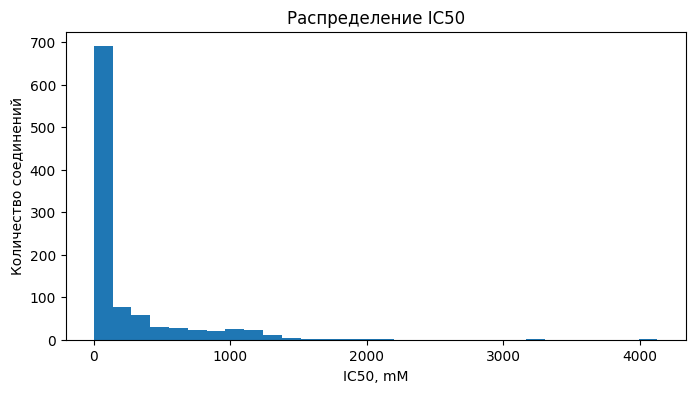

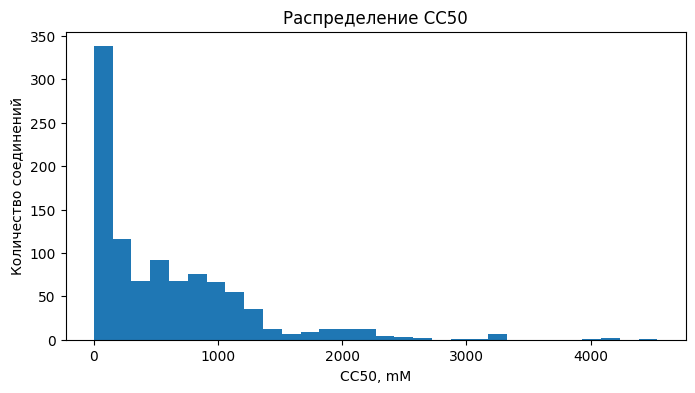

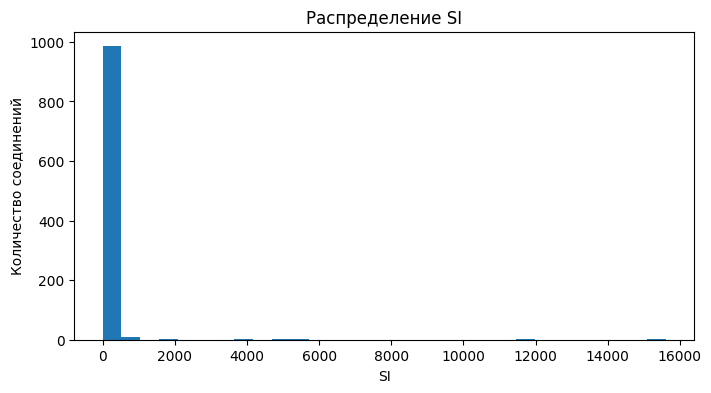

In [18]:
# 16. Распределение целевых переменных

# Строим гистограмму распределения IC50, чтобы увидеть характер значений этого показателя
plt.figure(figsize=(8, 4))
plt.hist(df['IC50, mM'], bins=30)
plt.title('Распределение IC50')
plt.xlabel('IC50, mM')
plt.ylabel('Количество соединений')
plt.show()

# Строим гистограмму распределения CC50, чтобы увидеть характер значений этого показателя
plt.figure(figsize=(8, 4))
plt.hist(df['CC50, mM'], bins=30)
plt.title('Распределение CC50')
plt.xlabel('CC50, mM')
plt.ylabel('Количество соединений')
plt.show()

# Строим гистограмму распределения SI, чтобы увидеть характер значений селективного индекса
plt.figure(figsize=(8, 4))
plt.hist(df['SI'], bins=30)
plt.title('Распределение SI')
plt.xlabel('SI')
plt.ylabel('Количество соединений')
plt.show()

### Вывод по целевым переменным

Целевыми переменными в данной работе являются `IC50, mM`, `CC50, mM` и `SI`.

Описательная статистика показывает диапазон значений, средние значения, медианы и возможное наличие выбросов в целевых переменных.

По графикам распределения можно оценить, что значения целевых переменных могут быть распределены неравномерно. Поэтому для дальнейшего моделирования важно сравнивать несколько алгоритмов машинного обучения, а не ограничиваться только одной моделью.

Переменная `SI` является особенно важной, так как она отражает селективность соединения и используется не только в задаче регрессии, но и в задаче классификации `SI > 8`.

In [19]:
# 18. Проверка типов данных

# Считаем количество столбцов каждого типа данных
df.dtypes.value_counts()

,count
int64,107
float64,107


In [20]:
# 19. Поиск нечисловых столбцов

# Находим столбцы, которые не относятся к числовому типу данных
non_numeric_columns = df.select_dtypes(exclude=['number']).columns

# Выводим список нечисловых столбцов
non_numeric_columns

Index([], dtype='object')

### Вывод по типам данных

Проверка типов данных показала, что в датасете отсутствуют нечисловые столбцы.

Это означает, что все признаки представлены в числовом формате и могут быть использованы для построения моделей машинного обучения без дополнительного кодирования категориальных переменных.

Таким образом, этап преобразования категориальных признаков не требуется.

In [21]:
# 21. Корреляция признаков с целевыми переменными

# Считаем матрицу корреляций между всеми числовыми столбцами
correlation_matrix = df.corr()

# Выводим признаки, которые сильнее всего связаны с IC50
correlation_matrix['IC50, mM'].sort_values(ascending=False).head(10)

,"IC50, mM"
"IC50, mM",1.000000
"CC50, mM",0.521346
fr_Ar_NH,0.245511
fr_Nhpyrrole,0.245511
fr_nitro,0.215948
FpDensityMorgan1,0.208710
BCUT2D_CHGLO,0.203161
BalabanJ,0.196842
FpDensityMorgan2,0.187991
MaxPartialCharge,0.179227


In [22]:
# 22. Признаки, наиболее связанные с CC50

# Выводим признаки, которые сильнее всего связаны с CC50
correlation_matrix['CC50, mM'].sort_values(ascending=False).head(10)

,"CC50, mM"
"CC50, mM",1.000000
"IC50, mM",0.521346
FpDensityMorgan1,0.293989
FpDensityMorgan2,0.256608
HallKierAlpha,0.215193
BCUT2D_CHGLO,0.205016
BalabanJ,0.189650
fr_Nhpyrrole,0.160234
fr_Ar_NH,0.160234
BCUT2D_LOGPLOW,0.157918


In [23]:
# 23. Признаки, наиболее связанные с SI

# Выводим признаки, которые сильнее всего связаны с SI
correlation_matrix['SI'].sort_values(ascending=False).head(10)

,SI
SI,1.000000
BalabanJ,0.162955
fr_NH2,0.160470
fr_Al_COO,0.102414
fr_COO,0.101115
fr_COO2,0.101115
VSA_EState4,0.087837
FpDensityMorgan1,0.087341
NHOHCount,0.079143
EState_VSA2,0.071385


### Вывод по корреляционному анализу

Корреляционный анализ позволил определить признаки, которые имеют наибольшую линейную связь с целевыми переменными `IC50, mM`, `CC50, mM` и `SI`.

Для переменной `SI` наиболее заметную положительную корреляцию показали признаки `BalabanJ`, `fr_NH2`, `fr_Al_COO`, `fr_COO`, `fr_COO2` и некоторые другие. При этом значения корреляции остаются относительно невысокими.

Это говорит о том, что связь между отдельными признаками и целевыми переменными может быть слабой в линейном смысле. Поэтому при дальнейшем моделировании важно использовать не только линейные модели, но и более сложные алгоритмы, способные учитывать нелинейные зависимости между признаками.

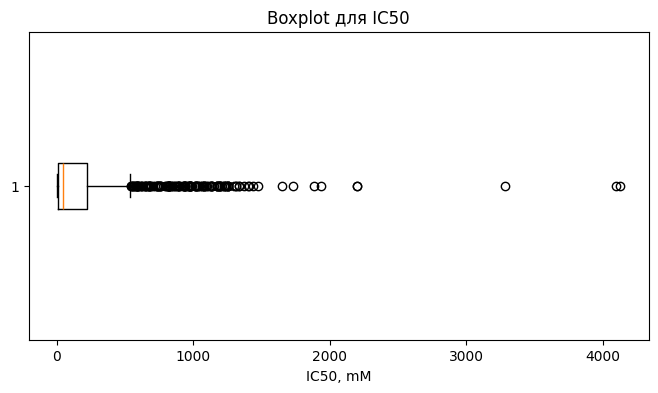

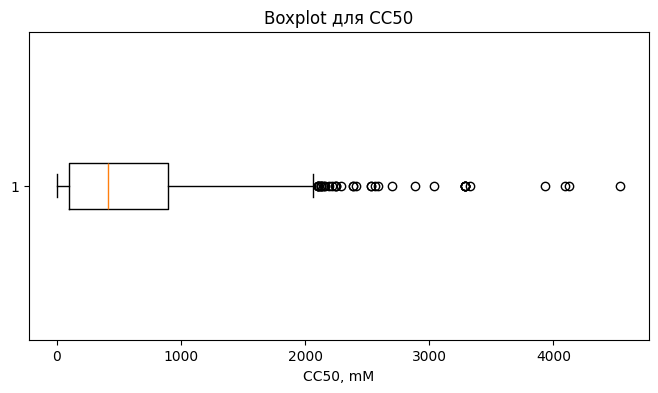

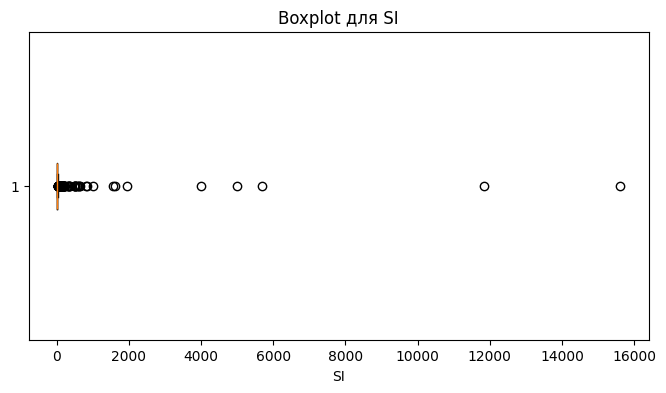

In [24]:
# 25. Проверка выбросов по целевым переменным

# Строим boxplot для IC50, чтобы увидеть возможные выбросы
plt.figure(figsize=(8, 4))
plt.boxplot(df['IC50, mM'], vert=False)
plt.title('Boxplot для IC50')
plt.xlabel('IC50, mM')
plt.show()

# Строим boxplot для CC50, чтобы увидеть возможные выбросы
plt.figure(figsize=(8, 4))
plt.boxplot(df['CC50, mM'], vert=False)
plt.title('Boxplot для CC50')
plt.xlabel('CC50, mM')
plt.show()

# Строим boxplot для SI, чтобы увидеть возможные выбросы
plt.figure(figsize=(8, 4))
plt.boxplot(df['SI'], vert=False)
plt.title('Boxplot для SI')
plt.xlabel('SI')
plt.show()

### Вывод по выбросам

По boxplot-графикам видно, что в целевых переменных `IC50, mM`, `CC50, mM` и `SI` могут присутствовать выбросы.

Для химических данных такие значения не обязательно являются ошибками: они могут отражать реальные особенности отдельных соединений с необычно высокой или низкой активностью.

Поэтому на этапе EDA выбросы не удаляются автоматически. Их влияние будет учитываться при дальнейшем построении и сравнении моделей машинного обучения.

In [25]:
# 27. Проверка масштаба признаков

# Убираем целевые переменные и оставляем только признаки
feature_columns = df.drop(columns=target_columns).columns

# Выводим описательную статистику по признакам
df[feature_columns].describe()

,Unnamed: 0,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.0,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1.001000e+03,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1.001000e+03,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.0,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.0,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,100

### Вывод по масштабу признаков

Описательная статистика признаков показывает, что разные признаки имеют разные диапазоны значений и разные масштабы.

Это важно учитывать при дальнейшем построении моделей. Для линейных моделей и моделей, чувствительных к масштабу признаков, может потребоваться стандартизация данных.

При этом древовидные модели, например Random Forest, обычно менее чувствительны к масштабу признаков. Поэтому на этапе моделирования будут сравниваться разные алгоритмы.

In [26]:
# 29. Сохранение обработанного датасета

# Сохраняем датасет после обработки пропусков в новый CSV-файл
df.to_csv('processed_chemical_data.csv', index=False)

# Проверяем, что файл успешно создан
print('Файл processed_chemical_data.csv успешно сохранён')

Файл processed_chemical_data.csv успешно сохранён


In [27]:
# 30. Скачивание обработанного датасета

# Импортируем files из Google Colab для скачивания файла на компьютер
from google.colab import files

# Скачиваем обработанный CSV-файл на компьютер
files.download('processed_chemical_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Итоговый вывод по EDA

В ходе разведочного анализа данных был изучен датасет химических соединений, содержащий числовые признаки молекул и целевые переменные `IC50, mM`, `CC50, mM` и `SI`.

Были выполнены следующие этапы:

- проведён первичный осмотр структуры датасета;
- проверены размеры данных, названия столбцов и типы признаков;
- обнаружены и обработаны пропущенные значения;
- проверено отсутствие полностью повторяющихся строк;
- изучены целевые переменные `IC50, mM`, `CC50, mM` и `SI`;
- построены графики распределений целевых переменных;
- проведён корреляционный анализ;
- проверено наличие возможных выбросов;
- сохранён обработанный датасет для дальнейшего построения моделей.

По результатам анализа можно сделать вывод, что датасет подходит для дальнейшего решения задач регрессии и классификации. Все признаки представлены в числовом формате, пропуски были заполнены медианными значениями, а дубликаты не обнаружены.

Корреляционный анализ показал, что отдельные признаки имеют ограниченную линейную связь с целевыми переменными. Поэтому на следующих этапах целесообразно сравнить разные модели машинного обучения, включая как линейные методы, так и более сложные алгоритмы, способные учитывать нелинейные зависимости.